 <h1 style="color:orange; font-weight:bold">🧹 Missing Values Handling — From Basic to Advanced </h1>

<h3 style="color:#f50000; font-weight:bold">🚀 What This Notebook Covers</h3>

<h5 style="color:#00f5ab; font-weight:bold">A Practical Journey from **Basic: (Mean, Median, Mode) | Advanced: Machine Learning, Deep Learning** for missing-value imputation.</h5>

<div align="center">

<img src="missing_valuess.png" alt="Missing Values Handling — From Basic to Advanced" width="100%">

</div>

### 👤 Author
**Shahzaib Abdul Khaliq**

🔗 **LinkedIn:** https://www.linkedin.com/in/shahzaibabdulkhaliq/  
💻 **GitHub:** https://github.com/Shahzaibabdulkhaliq0  
📊 **Kaggle:** https://www.kaggle.com/shezibaba

---



### 🧩 Methods Covered

**📊 Basic Statistical Methods**
- Mean
- Median
- Mode
- Forward Fill / Backward Fill

**🤖 Machine Learning**
- **KNN Imputation**
- **Iterative Imputation — Multivariate Imputation**

**🧠 Advanced Deep Learning**
- **Autoencoder-based Imputation**


### 📌 Method Progression

**Original Data Source → Statistical Methods → Machine Learning → Deep Learning**

> **Goal:** Start simple, understand the limitations, and progressively explore more advanced approaches to missing-value imputation.

In [62]:
## Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [63]:
## Load Dataset

data = sns.load_dataset('titanic')

In [64]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<h3 style="color:orange; font-weight:bold">🔥 Missing Values Heatmap</h3>

> 🚨 **Quick Check:** A heatmap gives us a **visual overview of missing values** in the dataset.
>
> 🟡 **Highlighted areas → Missing values**  
> ⚪ **Normal areas → Available values**
>
> 💡 **Why use it?**  
> It helps us **quickly identify which columns and rows contain missing data** before choosing an imputation method.
>
> **Rule:**  
> **First Visualize → Then Decide How to Handle Missing Values.**

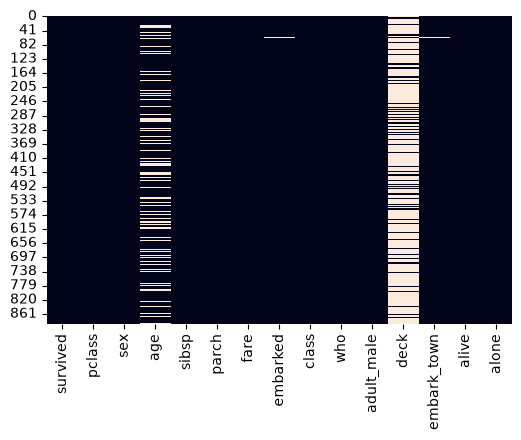

In [65]:
plt.figure(figsize=(6, 4))
sns.heatmap(data.isnull(), cbar=False)
plt.show()

In [66]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [67]:
data.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [68]:
round(data.isnull().sum() / len(data) * 100, 2).sort_values(ascending=False)

deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
sex             0.00
pclass          0.00
survived        0.00
fare            0.00
parch           0.00
sibsp           0.00
class           0.00
adult_male      0.00
who             0.00
alive           0.00
alone           0.00
dtype: float64

<h3 style="color:orange; font-weight:bold">📊 Mean Imputation</h3>

- **Mean = Average of the values**
- ⚠️ **Be careful:** Mean is **highly affected by outliers**.
- ❌ If outliers exist, **don't blindly use Mean**.
- ✅ In such cases, **Median is usually a safer choice**.

### Example

`10, 12, 13, 15, 100`

- `100` → **Outlier 🚨**
- Mean → gets pulled toward `100`
- Median → stays closer to the typical values

> 💡 **Rule to Remember:**  
> **Outliers present → Think Median first, not Mean.**

In [69]:
data.isnull().sum().sort_values(ascending=False).head(5)

deck           688
age            177
embarked         2
embark_town      2
sex              0
dtype: int64

In [70]:
# Calculate the mean
print(round(data['age'].mean(), 2))

29.7


In [71]:
# Now save and Update Dataset
data['age'] = data['age'].fillna(data['age'].mean())

In [72]:
data.isnull().sum().sort_values(ascending=False).head(5)

deck           688
embarked         2
embark_town      2
age              0
survived         0
dtype: int64

<h3 style="color:orange; font-weight:bold">📍 Median Imputation</h3>

- **Median = Middle value** when data is arranged in order.
- ✅ **Less affected by outliers**, so it is often preferred when outliers are present.

### Example

`10, 12, 13, 15, 100`

👉 **Median = 13**

> 💡 **Rule:** Outliers present → **Prefer Median.**

In [73]:
## Load Dataset

data = sns.load_dataset('titanic')

In [74]:
data.isnull().sum().sort_values(ascending=False).head()

deck           688
age            177
embarked         2
embark_town      2
sex              0
dtype: int64

In [75]:
# Calculate the mean
print(round(data['age'].median(), 2))

28.0


In [76]:
# Now save and Update Dataset
data['age'] = data['age'].fillna(data['age'].median())

In [77]:
data.isnull().sum().sort_values(ascending=False).head()

deck           688
embarked         2
embark_town      2
age              0
survived         0
dtype: int64

<h3 style="color:orange; font-weight:bold">🔹 Mode Imputation</h3>

- **Mode = Most frequently occurring value**
- ✅ Best suited for **categorical data**.
- 👉 Useful when missing values belong to categories.

### Example

`Male, Female, Male, Male, Female`

👉 **Mode = Male**

> 💡 **Rule:** Categorical data + missing values → **Consider Mode.**

In [78]:
# Create the data categorical data with mode and missing value
data = pd.DataFrame({'Fruit': ['Apple', 'Banana', 'Apple', 'Banana', 
            'Apple', 'Banana', 'Apple', 'Banana', 'Apple', 'Banana', np.nan, 'Banana']})

In [79]:
data

,Fruit
0,Apple
1,Banana
2,Apple
3,Banana
4,Apple
5,Banana
6,Apple
7,Banana
8,Apple
9,Banana


In [80]:
# Calculate the mean
data['Fruit'].mode()

0    Banana
Name: Fruit, dtype: str

In [81]:
data['Fruit'] = data['Fruit'].fillna(data['Fruit'].mode()[0])

In [82]:
data

,Fruit
0,Apple
1,Banana
2,Apple
3,Banana
4,Apple
5,Banana
6,Apple
7,Banana
8,Apple
9,Banana


<h3 style="color:orange; font-weight:bold">➡️ Forward Fill (ffill)</h3>

- **Forward Fill = Fill a missing value using the previous available value.**
- ✅ Useful when values follow a **sequence or time order**.
- ⚠️ Not suitable when the previous value may not represent the missing one.

### Example

`10, 20, NaN, 40`

👉 After Forward Fill:

`10, 20, 20, 40`

> 💡 **Rule:** Missing value → **Use the previous value.**

In [83]:
data = pd.DataFrame({
    'Fruit': ['Apple', None, None, 'Mango', None]
})

In [84]:
data

,Fruit
0,Apple
1,NaN
2,NaN
3,Mango
4,NaN


In [85]:
data['Fruit'].ffill()  # Previous value

0    Apple
1    Apple
2    Apple
3    Mango
4    Mango
Name: Fruit, dtype: str

In [86]:
data['Fruit'] = data['Fruit'].ffill()

In [87]:
data

,Fruit
0,Apple
1,Apple
2,Apple
3,Mango
4,Mango


<h3 style="color:orange; font-weight:bold">⬅️ Backward Fill (bfill)</h3>

- **Backward Fill = Fill a missing value using the next available value.**
- ✅ Useful when data follows a **sequence or time order**.
- ⚠️ The next value should reasonably represent the missing value.

### Example

`10, NaN, 30, 40`

👉 After Backward Fill:

`10, 30, 30, 40`

> 💡 **Rule:** Missing value → **Use the next value.**

In [88]:
data = pd.DataFrame({
    'Fruit': ['Apple', None, None, 'Mango', None]
})

In [89]:
data

,Fruit
0,Apple
1,NaN
2,NaN
3,Mango
4,NaN


In [90]:
data['Fruit'].bfill()   # Next value

# If NaN is at the end and there is no next value, bfill() cannot fill it.

0    Apple
1    Mango
2    Mango
3    Mango
4      NaN
Name: Fruit, dtype: str

In [91]:
data['Fruit'] = data['Fruit'].bfill()

In [92]:
data
# If NaN is at the end and there is no next value, bfill() cannot fill it.

,Fruit
0,Apple
1,Mango
2,Mango
3,Mango
4,NaN


<h1 style="color:orange; font-weight:bold">Advanced Methods</h1>

<h2 style="color:green; font-weight:bold">Machine Learning</h2>

<h3 style="color:orange; font-weight:bold">🤖 KNN Imputation</h3>

- **KNN = K-Nearest Neighbors**
- It fills missing values using **similar data points (neighbors)**.
- ✅ Useful when similar rows have similar feature values.
- ⚠️ Can be slower on **large datasets**.

### Example

Suppose `Age` is missing:

`25, 27, NaN, 26, 50`

KNN looks for the **most similar nearby records** and uses their values to estimate the missing `Age`.

> 💡 **Rule:** Missing value → **Find similar neighbors → Use their information.**

In [93]:
# Import Liberary
from sklearn.impute import KNNImputer

In [94]:
# Create the data
data = pd.DataFrame({'Age': [20, 21, 22, 23, 24, np.nan, 25, 26, 27, 28, 29, 50]})

In [95]:
data

,Age
0,20.0
1,21.0
2,22.0
3,23.0
4,24.0
5,NaN
6,25.0
7,26.0
8,27.0
9,28.0


In [96]:
# Initialize the KNNImputer
imputer = KNNImputer(n_neighbors=2)

In [97]:
%%time
# Replace the missing values with KNN imputation
data['Age'] = imputer.fit_transform(data[['Age']])

CPU times: total: 0 ns
Wall time: 9.49 ms


In [98]:
data

,Age
0,20.000000
1,21.000000
2,22.000000
3,23.000000
4,24.000000
5,26.818182
6,25.000000
7,26.000000
8,27.000000
9,28.000000


<h3 style="color:orange; font-weight:bold">🔄 Iterative Imputation — Multivariate Imputation</h3>

- **Iterative Imputation** estimates missing values by using the relationships between multiple features in the dataset.
- Instead of filling missing values with a simple **mean or median**, it uses an iterative process to make more informed estimates.
- The method models one feature with missing values using other available features and repeatedly updates the estimated values.
- 🔄 The process continues for multiple iterations until the imputed values become stable or the maximum number of iterations is reached.
- ✅ Useful when features have meaningful relationships with each other.
- ⚠️ It can be more computationally expensive than simple statistical methods.

### Example

Suppose we have:

`Age | Fare | Pclass | SibSp`

and some values in **Age** are missing.

👉 Iterative Imputation can use the available information from other features to estimate the missing **Age** values.

### 🧠 Why Use It?

**Mean/Median → Uses one feature's distribution**

**Iterative Imputation → Uses relationships between multiple features**

> 💡 **Rule:**  
> **Multiple related features + missing values → Consider Iterative Imputation.**

In [99]:
# Import Liberary
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd
import seaborn as sns

In [100]:
data = sns.load_dataset("titanic")

In [101]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [102]:
## Check Null Values

data.isnull().sum().sort_values(ascending=False).head()

deck           688
age            177
embarked         2
embark_town      2
sex              0
dtype: int64

In [103]:
# Initialize the IterativeImputer
imputer = IterativeImputer(max_iter=20, n_nearest_features=5, random_state=42)

In [104]:
%%time
## %%time  Used For Running Time Check (Optional)

# Replace the missing values with deep learning techniques
data['age'] = imputer.fit_transform(data[['age']])

CPU times: total: 0 ns
Wall time: 8.11 ms


In [105]:
data.isnull().sum().sort_values(ascending=False).head()

deck           688
embarked         2
embark_town      2
age              0
survived         0
dtype: int64

<h2 style="color:green; font-weight:bold">🧠 Deep Learning</h2>

<h3 style="color:orange; font-weight:bold">🧠 Autoencoder-Based Imputation</h3>

- **Autoencoder** is a Deep Learning model that learns patterns and relationships within the data.
- It can be used to **estimate missing values** by learning how the available features are related.
- The **Encoder** learns a compressed representation of the data, while the **Decoder** reconstructs the data.
- ✅ Useful for complex datasets where simple statistical methods may not capture the underlying patterns.
- ⚠️ More computationally expensive and complex than traditional imputation methods.

> 💡 **Rule:**  
> **Learn patterns → Reconstruct data → Estimate missing values**

## ⚠️ Advanced Method — Autoencoder

> 🚨 **Important:** Autoencoder is an **advanced Deep Learning approach** that can also be used to estimate missing values by learning patterns and reconstructing the data.
>
> ⚠️ **However, it is NOT recommended here.**  
> The methods covered above already handle the missing-value problem effectively.
>
> 🧠 **This section is included only as an advanced learning example — not as the preferred solution.**
>
> **Simple Methods → Practical Missing-Value Handling ✅**  
> **Autoencoder → Advanced / Extra Exploration ⚠️**

In [106]:
# Import StandardScaler to scale numerical features
from sklearn.preprocessing import StandardScaler

# Import Keras layers and Model to build the Autoencoder
from tensorflow.keras import layers, Model

In [107]:
# Load the original Titanic dataset
df_auto = sns.load_dataset('titanic')


In [108]:
# Select numerical features that will be used as Autoencoder input (X)
features = ['age', 'fare', 'sibsp', 'parch', 'pclass']

In [109]:
# Create X containing only the selected input features
X = df_auto[features].copy()

In [110]:
# Show the input data
X.head()

,age,fare,sibsp,parch,pclass
0,22.0,7.2500,1,0,3
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,3
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,3


In [111]:
# Keep only rows where all selected input values are available
X_complete = X.dropna()

In [112]:
# Create a scaler to put all features on a similar scale
scaler = StandardScaler()

In [113]:
# Learn scaling from complete data and convert the values into scaled values
X_scaled = scaler.fit_transform(X_complete)

In [114]:
# X_scaled is the scaled input that will be given to the Autoencoder
X_scaled.shape

(714, 5)

In [115]:
# Encoder compresses the input into a smaller representation
encoded = layers.Dense(4, activation='relu')(input_layer)

NameError: name 'input_layer' is not defined

In [ ]:
# Decoder reconstructs the original input from the compressed representation
decoded = layers.Dense(len(features), activation='linear')(encoded)

In [ ]:
# Create the Autoencoder using input and reconstructed output
autoencoder = Model(input_layer, decoded)

In [ ]:
# Tell the model to use Adam optimizer and Mean Squared Error loss
autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
%%time

# Train the Autoencoder using X as both input and expected output
autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=30,
    batch_size=32,
    verbose=0
)

CPU times: total: 5 s
Wall time: 5.43 s


In [ ]:
##  X_scaled → Encoder → compressed data → Decoder → reconstructed X

In [ ]:
# Create a copy of the original input data
X_filled = X.copy()

In [ ]:
# Temporarily fill missing values with the median
# This gives the Autoencoder a complete input to work with
X_filled = X_filled.fillna(X_filled.median())

In [ ]:

# Convert the temporary data to the same scale used during training
X_filled_scaled = scaler.transform(X_filled)

In [ ]:
# Ask the trained Autoencoder to reconstruct the input
X_reconstructed_scaled = autoencoder.predict(
    X_filled_scaled,
    verbose=0
)

In [ ]:

# Convert reconstructed values back to their original scale
X_reconstructed = scaler.inverse_transform(X_reconstructed_scaled)

In [ ]:

# Convert reconstructed values into a DataFrame
X_reconstructed = pd.DataFrame(
    X_reconstructed,
    columns=features,
    index=X.index
)

In [ ]:

# Show the estimated values
X_reconstructed.head()

,age,fare,sibsp,parch,pclass
0,21.259418,9.607740,0.854208,0.062491,2.538478
1,36.193474,79.390366,0.494164,0.023187,1.224576
2,27.830536,-2.219437,0.238951,0.166059,2.693655
3,32.827755,68.390358,0.476243,0.136804,1.346390
4,31.162022,6.324451,0.195609,0.088577,2.591263


In [ ]:
# Create a copy so the original X remains unchanged
X_imputed = X.copy()

In [ ]:

# Go through each feature one by one
for column in features:

    # Find the rows where this column originally had missing values
    missing_rows = X[column].isna()

    # Replace ONLY the missing values with Autoencoder estimates
    X_imputed.loc[missing_rows, column] = X_reconstructed.loc[
        missing_rows, column
    ]

In [ ]:

# Check how many missing values remain
X_imputed.isnull().sum()

age       0
fare      0
sibsp     0
parch     0
pclass    0
dtype: int64

<h3 style="color:orange; font-weight:bold">🗑️ Deleting Columns</h3>

- If a column has **70–80%+ missing values**, deleting it can be considered.
- ⚠️ **But don't delete it blindly.**
- First, check whether the column has an important **relationship with the target or other variables**.
- Make sure removing it will **not remove useful predictive information**.

### 🔍 Example — Titanic Dataset

Suppose the **`deck`** column has a very high percentage of missing values.

Before deleting `deck`, check whether it has a meaningful relationship with **`survived` (target `y`)**.

👉 If `deck` contains useful information for predicting survival, deleting it may reduce model performance.

> 💡 **Rule:** High missing values ≠ Automatically Delete.  
> **Check its predictive value first.**

# 🎯 Final Takeaway

Missing values do not have a **single best solution**.

The right approach depends on:

- 📊 **Data distribution**
- 🚨 **Outliers**
- 🧩 **Data type**
- 🔗 **Relationships between features**
- 🎯 **Target variable**
- 📈 **Dataset complexity**

### 🧠 Remember

> **Don't just fill missing values — understand why they are missing and choose the method accordingly.**

**Simple Data → Statistical Methods**  
**Complex Patterns → Machine Learning / Deep Learning**

---

### 🚀 What's Next?

**Explore → Experiment → Compare → Validate → Improve**

Thank you for exploring this notebook! 🙌